<a href="https://colab.research.google.com/github/taniaalina/Telecom-Analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print ()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  
   **Dentro del df users**
  Se encuentran dos columnas con valores faltantes:
  - city con el 11.73%
  - churn_date con el 88.35%

  **Dentro del df usage**
    Existen 3 columans con datos faltantes:
    - date con el 0.13%
    - duration con  el 55.19%
    - length con el 44.74%
      
- Indica qué harías: ¿imputar, eliminar, ignorar?

  
**Del df users:**
- La columna 'city' se investigará para imputar o dejar como nulos
- La columna 'churn_date' tiene un alto porcentaje de valores nulos, lo que puede determinar que corresponde a los clientes que no han cancelado. Por lo que se sugiere hacer un análisis por separado de los usuarios que han cancelado su plan.
**Del df usage:**
- La columna 'date' se pretende imputar
- La columna 'duration' se refiere a la dureación de llamadas que se infiere corresponden a minutos y segundos, por lo que va relacionada con la columna 'type' y se considera la razón por la que se muestran tantos datos faltantes, ya que no todos los registros corresponden a llamadas.
- La columna 'length' hace referencia a la longitud de los textos enviados, por lo que, al igual que la columna anterior, se encuentra relacionada con la columna 'type' y la razón de los datos faltantes puede deberse a que no todos los registros corresponden a textos enviados.
  

  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Tiene 4,000 registros que comienzan a contarse con el registro 10,000 y se identifica por ser una numeración consecutiva.
- La columna `age` Tiene 4,000 registros, pero se encuentra un sentinel -999 que está afectando a la estadística.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`consisten en numeración continua con 4,000 registros en total. La columna 'id' comienza su conteo en el número 1 y la columna 'user_id' comienza su conteo en el número 10,0000. No se consideran relevantes para este análisis.
- La columna 'duration' tiene nun total de 17,924 registros con una variación estandar mayor al promedio, los valores que considera son  de 0 a 120 que se infiere corresponden a minutos y segundos de duración de las llamadas. Se considera que existen muchos valores faltantes puesto que se relaciona con la columna 'type' y solamente ingresa información cuando se trata de llamadas.
- La columana 'length' tiene 22,104 registros con valores entre 0 y 1,490, al igual que la columna anterior, se refiere a la longitud de los mensajes, por  lo que también está relacionada con la columna 'type' y se supone que contiene la información cuando el registro se trata solamente de mensajes.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
for columna in columnas_user:
    print(f'Categorias de {columna}:')
    print(users[columna].unique())
    print ()

Categorias de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Categorias de plan:
['Basico' 'Premium']



- La columna `city` Tiene valores faltantes, con 7 categorias, siendo la ciudad más frecuente Boogtá con 808 registros
- La columna `plan` Tiene los 4,000 registros del df en 2 categorías, que coinciden con el número de planes que se están analizando en el df 'plans', siendo el más frecuente el Básico con  2,595 registros.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` Tiene 40,000 registros con  2 categorías siendo la más frecuente 'text' con  22,092 registros.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En la columna 'city' del df users se encuentran valores nulos (nan) y un sentinel (?)

- ¿Qué acción tomarías?  Se recomienda convertir el sentinel a valor nulo para que no interfiera con el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce',utc=True)

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce',utc=True)

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se ecuentran datos de los años 2022, 2023, 2024 y 2026

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())


2024.0    39950
Name: date, dtype: int64


En 'date', Solamente aparcen los registros del año 2024
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En el df 'users' si aparecen años pasados como 2022 y 2023, así como tambien 40 registros del año 2026
- ¿Qué harías con ellas?
- Si el análisis que se requiere es exclusivo del año 2024, se recomienda filtrar los registros del año 2024 exclusivamente.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999.000000, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']= users['city'].str.replace('?', 'NA')

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] =np.where(users['reg_date'].dt.year==2026, pd.NaT, users['reg_date'])

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

In [ ]:
#Filtrar users por el año 2024
users_2024=users[users['reg_date'].dt.year==2024]
print(users_2024.head())

      user_id first_name last_name   age  city  \
2666    12666      Mateo    Garcia  20.0  Cali   
2667    12667     Carlos     Gomez  72.0  Cali   
2668    12668        Ana    Torres  21.0  CDMX   
2669    12669      Sofia    Garcia  58.0  CDMX   
2670    12670        Ana    Garcia  54.0   MTY   

                                reg_date     plan churn_date  
2666           2024-01-01 00:00:00+00:00  Premium        NaN  
2667 2024-01-01 06:34:17.914478624+00:00  Premium        NaN  
2668 2024-01-01 13:08:35.828957240+00:00   Basico        NaN  
2669 2024-01-01 19:42:53.743435864+00:00   Basico        NaN  
2670 2024-01-02 02:17:11.657914480+00:00  Premium        NaN  


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se confirma que existe una relación entre las columnas 'duration' y 'length' con 'type', ya que se considera que la columna  'duration' hace referencia a la duración de las llamadas, por lo tanto los registros de envío de texto no contarán con ese valor.
De igual forma la columna 'length' corresponde a la longitud del texto enviado, por lo que cuando se registran llamadas, el dato de length es inexistente.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype              
---  ------    --------------  -----              
 0   id        40000 non-null  int64              
 1   user_id   40000 non-null  int64              
 2   type      40000 non-null  object             
 3   date      39950 non-null  datetime64[ns, UTC]
 4   duration  17924 non-null  float64            
 5   length    22104 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,id,duration,length,is_text,is_call
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


In [ ]:
usage_agg['user_id'].nunique()

3999

In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call': 'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users_2024, on = ['user_id'], how='inner')
user_profile.head(5)

,user_id,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date
0,12666,275886,11.50,610.0,13,3,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN
1,12667,233698,33.27,133.0,3,7,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN
2,12668,127258,87.56,189.0,5,7,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN
3,12669,164545,27.62,179.0,4,5,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864+00:00,Basico,NaN
4,12670,294091,31.90,496.0,9,4,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480+00:00,Premium,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1330 entries, 0 to 1329
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   user_id               1330 non-null   int64              
 1   id                    1330 non-null   int64              
 2   cant_minutos_llamada  1330 non-null   float64            
 3   length                1330 non-null   float64            
 4   cant_mensajes         1330 non-null   int64              
 5   cant_llamadas         1330 non-null   int64              
 6   first_name            1330 non-null   object             
 7   last_name             1330 non-null   object             
 8   age                   1330 non-null   float64            
 9   city                  1169 non-null   object             
 10  reg_date              1330 non-null   datetime64[ns, UTC]
 11  plan                  1330 non-null   object             
 12  churn_

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['cant_minutos_llamada', 'length', 'cant_mensajes', 'cant_llamadas', 'age']
for col in columnas_numericas:
    print(f'Resumen estadístico de {col}:')
    print('Media:', round(user_profile[col].mean(),2))
    print('Mediana:', user_profile[col].median())
    print('Mínimo:', user_profile[col].min())
    print('Máximo:', user_profile[col].max())
    print('Número de Registros:', user_profile[col].count())
    print('--------------------------------')
    print()


Resumen estadístico de cant_minutos_llamada:
Media: 24.13
Mediana: 20.325
Mínimo: 0.0
Máximo: 155.69
Número de Registros: 1330
--------------------------------

Resumen estadístico de length:
Media: 290.07
Mediana: 270.5
Mínimo: 0.0
Máximo: 2028.0
Número de Registros: 1330
--------------------------------

Resumen estadístico de cant_mensajes:
Media: 5.5
Mediana: 5.0
Mínimo: 0
Máximo: 16
Número de Registros: 1330
--------------------------------

Resumen estadístico de cant_llamadas:
Media: 4.56
Mediana: 4.0
Mínimo: 0
Máximo: 13
Número de Registros: 1330
--------------------------------

Resumen estadístico de age:
Media: 48.41
Mediana: 48.0
Mínimo: 18.0
Máximo: 79.0
Número de Registros: 1330
--------------------------------



In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.656391
Premium    0.343609
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

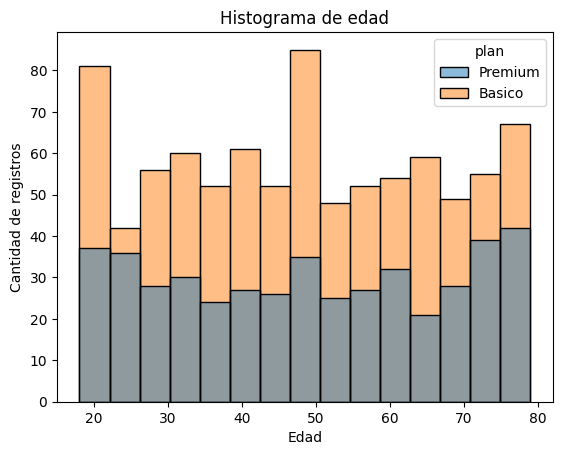

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=15, color=['skyblue', 'green'])
plt.title('Histograma de edad')

plt.xlabel('Edad')

plt.ylabel('Cantidad de registros')
plt.show()

💡Insights:
- El tipo de distribución que  presenta la variable edad es simétrica, con su pico más alto entre los 45 y 50 años
  La prorporción entre tipo de plan (básico y premium) es muy similar en los grupos de edades a exepción del grupo de más de 70 años en donde se observa un  repunte del plan premium, lo mismo ocurre con los usuarios entre las edades de 22 a 25 años, que prefieren el plan premium.


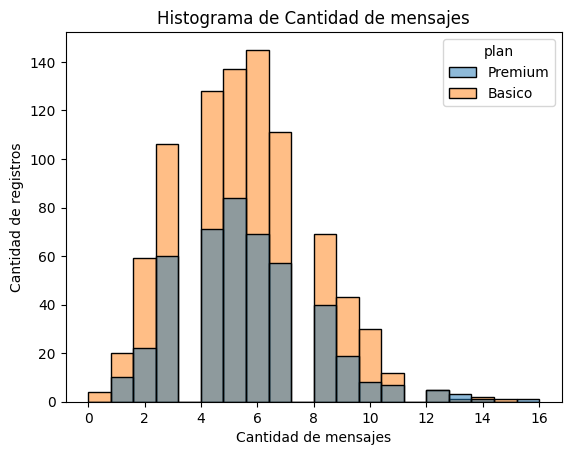

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20, color=['skyblue', 'green'])
plt.title('Histograma de Cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de registros')
plt.show()

💡Insights:
- Se observa que la distribución de los datos presenta un ligero sesgo a la derecha con un valor máximo de 16 mensajes,
- Es  más frecuente que los usuarios manden entre 4 a 7 mensajes.
- El segmento premium se caracteriza por usar más el servicio de mensajería.

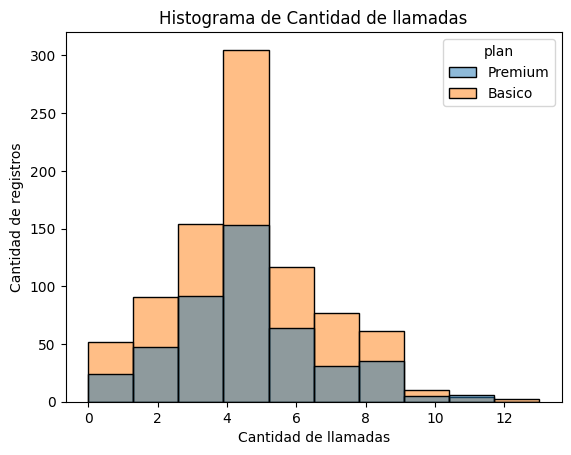

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, color=['skyblue', 'green'])
plt.title('Histograma de Cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de registros')
plt.show()

💡Insights:
- La Distribución se observa normal con un ligero sesgo a la derecha que considera como valor máximo 13 llamadas.
- Tanto el segmento premium como el básico presentan comportamientos similares, siendo el promedio 4.56 llamadas y la mediana de 4

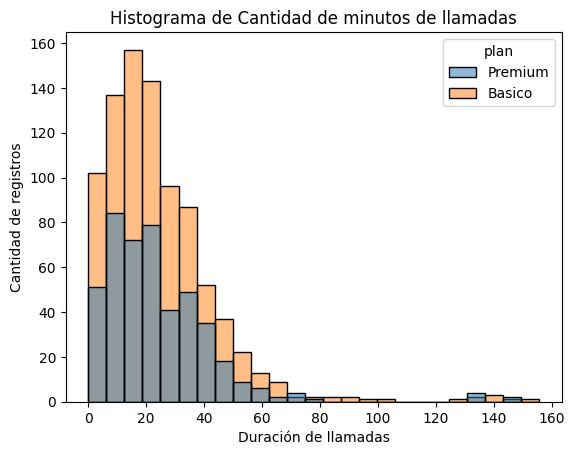

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=25, color=['skyblue', 'green'])
plt.title('Histograma de Cantidad de minutos de llamadas')
plt.xlabel('Duración de llamadas')
plt.ylabel('Cantidad de registros')
plt.show()

💡Insights:
-La distribución presenta un sesgo a la derecha, con valores extremos de 155.69 minutos como máximo
El comportamiento de la duración de llamadas se nota similar entre los dos segmentos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

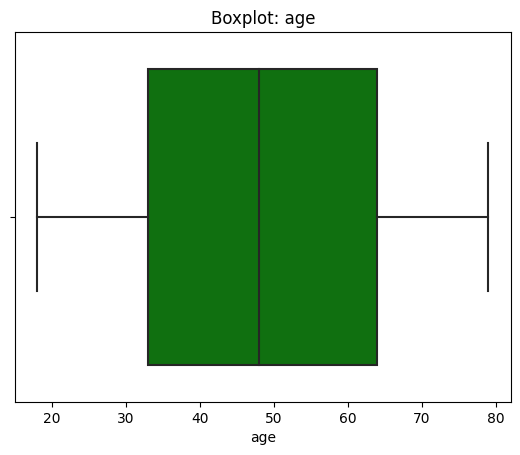

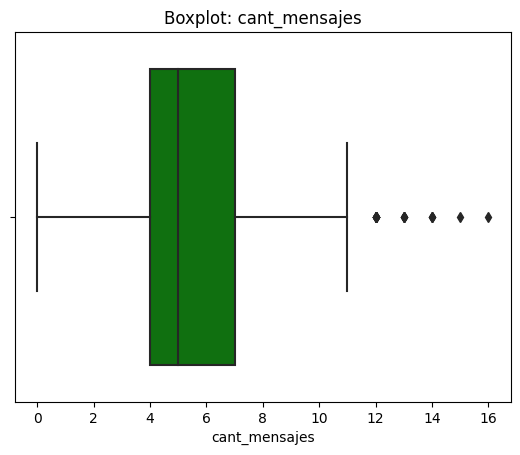

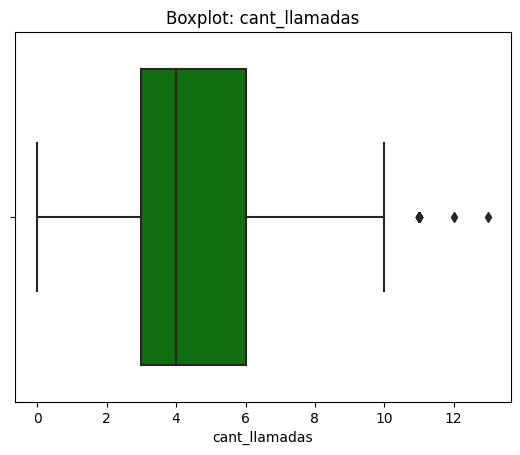

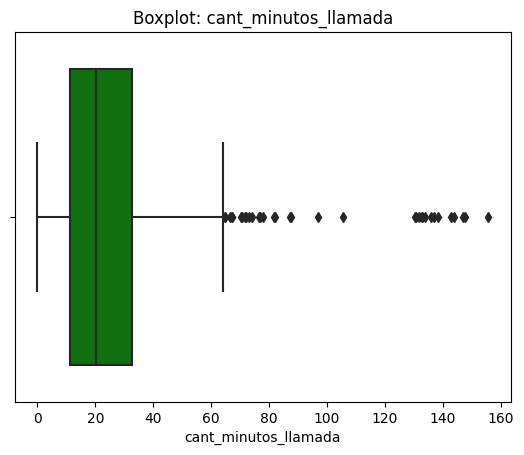

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='green')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers, tiene una distribución  normal
- cant_mensajes: Presenta unos valores considereados como atípicos, sin embargo no son  extremos
- cant_llamadas: De igual forma tiene unos pocos valores atípicos leves hacia la derecha
- cant_minutos_llamada: Presenta una distribución con sesgo hacia la derecha, con valores atípicos extremos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    upper=Q3+1.5*IQR
    print(f'Límite superior de {col}:', upper)


Límite superior de cant_mensajes: 11.5
Límite superior de cant_llamadas: 10.5
Límite superior de cant_minutos_llamada: 64.35749999999999


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    upper=Q3+1.5*IQR
    maximo=user_profile[col].max()
    print(f'Límite superior de {col}:', upper)
    print(f'Valor Máximo de {col}', maximo)
    print('--------------------------------')
    print()

Límite superior de cant_mensajes: 11.5
Valor Máximo de cant_mensajes 16
--------------------------------

Límite superior de cant_llamadas: 10.5
Valor Máximo de cant_llamadas 13
--------------------------------

Límite superior de cant_minutos_llamada: 64.35749999999999
Valor Máximo de cant_minutos_llamada 155.69
--------------------------------



💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Se mantienen outliers debido a que no son valores extremos
- cant_llamadas: mantener o no outliers, porqué? Se mantienen outliers debido a que no son valores extremos
- cant_minutos_llamada: mantener o no outliers, porqué? Se caparán los outliers ya que presenta valores atípicos muy altos, más del doble del límite superior.

In [ ]:
#Winsorización columna 'cant_min_llamada'
upper=user_profile['cant_minutos_llamada'].quantile(0.99)
user_profile['cant_min_llamada_cap'] = np.clip(user_profile['cant_minutos_llamada'],a_min = None, a_max = upper)
print(user_profile[['cant_minutos_llamada', 'cant_min_llamada_cap']].describe())

       cant_minutos_llamada  cant_min_llamada_cap
count           1330.000000           1330.000000
mean              24.126669             23.962796
std               19.458620             18.521141
min                0.000000              0.000000
25%               11.332500             11.332500
50%               20.325000             20.325000
75%               32.542500             32.542500
max              155.690000            123.069900


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def uso (row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']
    if llamadas<5 & mensajes<5:
        return 'Bajo uso'
    elif llamadas<10 & mensajes<10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] =user_profile.apply(uso,axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_cap,grupo_uso
0,12666,275886,11.50,610.0,13,3,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,11.50,Uso medio
1,12667,233698,33.27,133.0,3,7,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,33.27,Alto uso
2,12668,127258,87.56,189.0,5,7,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,87.56,Alto uso
3,12669,164545,27.62,179.0,4,5,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864+00:00,Basico,NaN,27.62,Alto uso
4,12670,294091,31.90,496.0,9,4,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480+00:00,Premium,NaN,31.90,Uso medio


In [ ]:
user_profile['grupo_uso'].value_counts(normalize=True)

Alto uso     0.744361
Uso medio    0.140602
Bajo uso     0.115038
Name: grupo_uso, dtype: float64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def seg_edad (row):
    edad =row['age']
    if edad<30 :
        return 'Joven'
    elif edad<60 :
        return 'Adulto'
    else:
        return 'Adulto mayor'

user_profile['grupo_edad'] =user_profile.apply(seg_edad,axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_cap,grupo_uso,grupo_edad
0,12666,275886,11.50,610.0,13,3,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00+00:00,Premium,NaN,11.50,Uso medio,Joven
1,12667,233698,33.27,133.0,3,7,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624+00:00,Premium,NaN,33.27,Alto uso,Adulto mayor
2,12668,127258,87.56,189.0,5,7,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240+00:00,Basico,NaN,87.56,Alto uso,Joven
3,12669,164545,27.62,179.0,4,5,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864+00:00,Basico,NaN,27.62,Alto uso,Adulto
4,12670,294091,31.90,496.0,9,4,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480+00:00,Premium,NaN,31.90,Uso medio,Adulto


In [ ]:
user_profile['grupo_edad'].value_counts(normalize=True)

Adulto          0.493985
Adulto mayor    0.318797
Joven           0.187218
Name: grupo_edad, dtype: float64

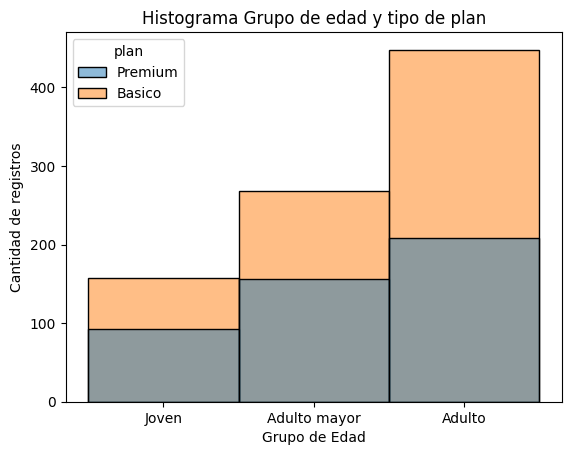

In [ ]:
sns.histplot(data=user_profile, x='grupo_edad', hue='plan', bins=3, color=['skyblue', 'green'])
plt.title('Histograma Grupo de edad y tipo de plan')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de registros')
plt.show()

In [ ]:
user_profile.groupby(['grupo_edad','plan']).count()

user_id   id  cant_minutos_llamada  length  \
grupo_edad   plan                                                  
Adulto       Basico       448  448                   448     448   
             Premium      209  209                   209     209   
Adulto mayor Basico       268  268                   268     268   
             Premium      156  156                   156     156   
Joven        Basico       157  157                   157     157   
             Premium       92   92                    92      92   

                      cant_mensajes  cant_llamadas  first_name  last_name  \
grupo_edad   plan                                                           
Adulto       Basico             448            448         448        448   
             Premium            209            209         209        209   
Adulto mayor Basico             268            268         268        268   
             Premium            156            156         156        156   
Joven        Basico             157            157         157        157   
             Premium             92             92          92         92   

                      age  city  reg_date  churn_date  cant_min_llamada_cap  \
grupo_edad   plan                                                             
Adulto       Basico   448   392       448          52                   448   
             Premium  209   184       209          32                   209   
Adulto mayor Basico   268   236       268          33                   268   
             Premium  156   136       156          18                   156   
Joven        Basico   157   140       157           9                   157   
             Premium   92    81        92           9                    92   

                      grupo_uso  
grupo_edad   plan                
Adulto       Basico         448  
             Premium        209  
Adulto mayor Basico         268  
             Premium        156  
Joven        Basico         157  
             Premium         92

In [ ]:
user_profile.groupby(['grupo_edad','grupo_uso']).count()

user_id   id  cant_minutos_llamada  length  \
grupo_edad   grupo_uso                                               
Adulto       Alto uso       505  505                   505     505   
             Bajo uso        69   69                    69      69   
             Uso medio       83   83                    83      83   
Adulto mayor Alto uso       303  303                   303     303   
             Bajo uso        52   52                    52      52   
             Uso medio       69   69                    69      69   
Joven        Alto uso       182  182                   182     182   
             Bajo uso        32   32                    32      32   
             Uso medio       35   35                    35      35   

                        cant_mensajes  cant_llamadas  first_name  last_name  \
grupo_edad   grupo_uso                                                        
Adulto       Alto uso             505            505         505        505   
             Bajo uso              69             69          69         69   
             Uso medio             83             83          83         83   
Adulto mayor Alto uso             303            303         303        303   
             Bajo uso              52             52          52         52   
             Uso medio             69             69          69         69   
Joven        Alto uso             182            182         182        182   
             Bajo uso              32             32          32         32   
             Uso medio             35             35          35         35   

                        age  city  reg_date  plan  churn_date  \
grupo_edad   grupo_uso                                          
Adulto       Alto uso   505   436       505   505          65   
             Bajo uso    69    63        69    69           9   
             Uso medio   83    77        83    83          10   
Adulto mayor Alto uso   303   261       303   303          39   
             Bajo uso    52    47        52    52           5   
             Uso medio   69    64        69    69           7   
Joven        Alto uso   182   159       182   182          14   
             Bajo uso    32    28        32    32           2   
             Uso medio   35    34        35    35           2   

                        cant_min_llamada_cap  
grupo_edad   grupo_uso                        
Adulto       Alto uso                    505  
             Bajo uso                     69  
             Uso medio                    83  
Adulto mayor Alto uso                    303  
             Bajo uso                     52  
             Uso medio                    69  
Joven        Alto uso                    182  
             Bajo uso                     32  
             Uso medio                    35

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

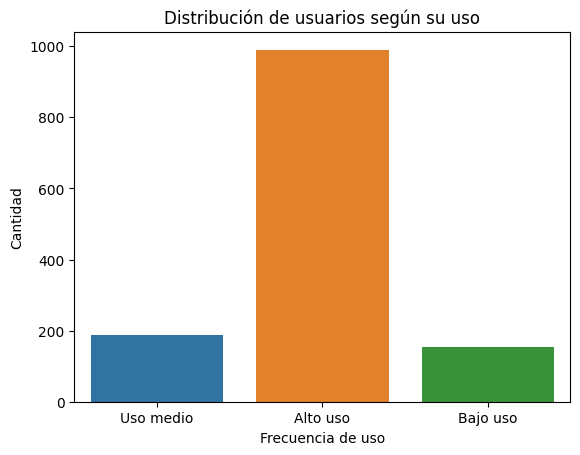

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile)
plt.title('Distribución de usuarios según su uso')
plt.xlabel('Frecuencia de uso')
plt.ylabel('Cantidad')
plt.show()

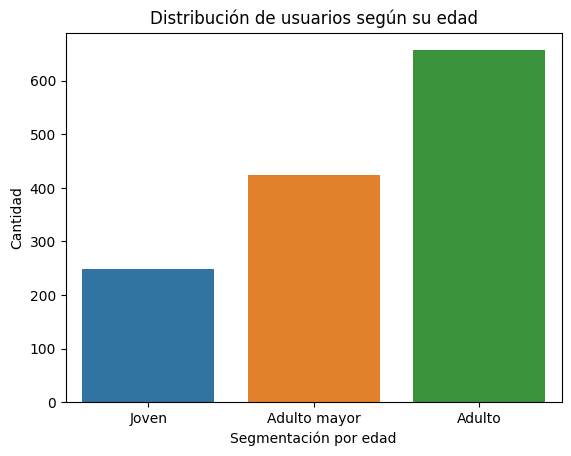

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile)
plt.title('Distribución de usuarios según su edad')
plt.xlabel('Segmentación por edad')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo
Se analizaron  3 data sets, en los cuales, se encontraron los siguientes problemas en los datos
⚠️ **Problemas detectados en los datos**
- En el data set denominado 'users' se encontraron dos columnas con valores faltantes: 'city' con el 11.73% y 'churn_date' con  el 88.35%. Ésta última no se consideró de relevancia puesto que se trata de fecha de cancelación
- En el data set 'usage', se detectaron  3 columnas con valores faltantes: 'date' con  el 0.13%, 'duration' 55.19% y 'length' con el 44.74%. Estas dos últimas no se consideraron relevantes ya que se determinó su relación con la columna 'type' que distingue entre llamadas o mensajes y 'duration' hace  referencia a la duración de la llamada y 'length' a la  longitud del mensaje
-Se encontraron outliers en las columnas 'cant_mensajes', 'cant_llamadas' y 'cant_min_llamada', las dos primeras columnas no influyen dentro del análisis, puesto que son pocos valores y no son valores tan extremos, se considera que aún cuando son valores atípicos no muestran un comportamiento no posible. Y en relación al outlier de la columna 'cant_min_llamada', si se encontró un valor muy fuera de límite, que convendría analizar posteriormente para corroborar alguna falla en el sistema de registro. Este valor se capó al percentil 99.

🔍 **Segmentos por Edad**
- Se segmentaron a los usuarios en 3 categorías, de acuerdo a su edad, jovenes menores de 30 años, adultos entre 31 y 60 años y adultos mayores usuarios mayores de 60 años.
- Se observa que nuestro mayor segmento son los Adultos con el 49.40%, seguido del grupo de adulto mayor con el 31.88%. Es relevante mencionar que los tres segmentos se comportan muy similares en la contratación del tipo de plan con el 63 al 68% contrata el plan básico y entre 32 al 37% contrata un plan premium.


📊 **Segmentos por Nivel de Uso**
- Se encontraron 3 segmentos de acuerdo al uso(alto, medio y bajo), siendo la gran mayoría de 'Alto uso' (74.44%)clasificando aquellos que realizan más de 10 llamadas y 10 mensajes, en segundo lugar el segmento de medio uso con el 14.06% considetando aquellos que realizan más de 5 y menos de 10 llamadas y mensajes.
- De los segmentos por edad, se identificó que entre el 73% al 77% tienen un alto uso, del 12% al 16% un uso medio y del 10% al 13% un bajo uso.

➡️ Esto sugiere que la empresa tiene como segmento principal a usuarios adultos con un alto nivel de uso, el plan más contratado es el básico, aun cuando se detectaron algunos outliers en la cantidad de llamadas y mensajes no se consideran fuera del comportamiento normal, puesto que son  valores atípicos pero no extremos. No se detecta un comportamiento diferenciador entre los segmentos, puesto que los 3 segmentos en base a la edad presentan un alto uso.


💡 **Recomendaciones**
- Revisar la propuesta  de valor del  plan premium logrando una diferenciación mas marcada.
- Una oportunidad de negocio es el enfoque en el segmento joven

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`